# Informed pandemic intensity prior construction

The goal of this notebook is to construct an informed prior over the parameters of our pandemic intensity distribution:

$$
\mathrm{F_X}(x; p_0, \xi, \sigma) = \begin{cases}
     1 - p_0 & x < \mu \\
        1 - p_0\left(1+\xi\dfrac{x-\mu}{\sigma}\right)^{-1/\xi} & x \geq \mu
\end{cases}
$$

where $p_0$ is the annual probability that an epidemic emerges and $\xi$, $\mu$ and $\sigma$ are the shape, location, and scale parameters of a generalized Pareto distribution (GPD) representing pandemic intensity conditional on arrival. For simplicity we will henceforth denote $F_X(x;p_0, \xi, \sigma)$ as $F_X$.

Previously I tried to use a [reference prior approach](https://projecteuclid.org/journals/bayesian-analysis/volume-10/issue-1/Overall-Objective-Priors/10.1214/14-BA915.full), which has the property of minimizing the expected informational contribution of the prior to the posterior distribution. Unfortunately, the method proved computationally vexing.

A less knowledge agnostic approach would likely attenuate our computational difficulties, but demands defining a prior that accurately represents our beliefs. The table below lists some methods for defining such priors alongside their pros and cons:

| Approach | Pros | Cons |
| -------- | ---- | ---- |
| 1. Base priors on estimates from existing literature | - Simple<br> | - Uses data twice<br> |
| 2. Estimate central prior moments using expert + amateur forecasts, then assume wide uncertainty range | - Less explicit recycling of data<br> - Relatively simple | - Involves some judgement calls|
| 3. Estimate full prior distributions using expert + amateur forecasts | - All parameters fit from data<br> - Less explicit recycling of data | - Very complex<br> - Involves some judgement calls |

I'll go through what each approach would involve and then prototype approach 2.

## 1. Base priors on existing literature

Ganqi suggests we can choose prior distributions that capture plausible parameters ranges suggested by estimates from Fan et al. (2018), Bernstein et al., Cirillo and Taleb (2020), and Marani et al. (2023). Some considerations are:
- Many are using the same data that we are to fit the same model. It seems incorrect to use the same data for the prior and posterior.
- Only Marani et al. (2021) and Bernstein et al. (2022) give us arrival rates ($p_0$). But I think we really don't like the Marani arrival rate.
- If we use Taleb log transform, arguably on their estimates are appropriate.

This approach is otherwise possible and straightforward.

## 2. Estimate central prior moments using forecasts

I've found quantitative subjective forecasts of pandemic risk on [Metaculus](https://www.metaculus.com/), an amateur forecasting website, and in the [Existential Risk Persuasion Tournament](https://forecastingresearch.org/xpt) (XPT), a formal forecasting event including expert forecasters  (superforecasters) and subject matter experts. The relevant forecasts from both platforms are summarized in the table below. Note that not all of them have the ideal units (intensity vs severity) or cleanly represent non-anthropogenic pandemic risk.


| Forecast                                           | Central estimate type   | Central estimate | Uncertainty band type | Low   | High | N   | Source                                                                 | Notes               |
|----------------------------------------------------|----------------|----------|------------------|-------|------|-----|------------------------------------------------------------------------|---------------------|
| Natural pandemic killing 1% of pop by 2030            | Median         | 0.5%     | IQR              | 0.1%  | 1%   | 88  | [Existential risk persuasion tournament](https://forecastingresearch.org/xpt) (Superforecasters)         | - Uses severity units                    |
| Natural pandemic killing 1% of pop by 2050            | Median         | 1.69%    | IQR              | 0.5%  | 5%   | 88  | [Existential risk persuasion tournament](https://forecastingresearch.org/xpt) (Superforecasters)         |  - Uses severity units                  |
| Number of PHEICs killing > 10k by 2024     | Median         | 0.5      | IQR              | 0     | 1    | 33  | [Existential risk persuasion tournament](https://forecastingresearch.org/xpt) (Superforecasters)         | - Includes lab leak + terror risk<br> - Technically demands severity unit conversion, but would put below detection threshold                    |
| Number of PHEICs killing > 10k by 2030     | Median         | 2        | IQR              | 1.9   | 3    | 33  | [Existential risk persuasion tournament](https://forecastingresearch.org/xpt) (Superforecasters)         | - Includes lab leak + terror risk<br> - Technically demands severity unit conversion, but would put below detection threshold                    |
| Natural pandemic killing > 10M by 2026     | Weighted Mean  | 10%      | Not documented   | 5%    | 25%  | 238 | [Metaculus](https://www.metaculus.com/questions/247/naturally-originating-pandemic-before-2026/)  |                     |
| Flu with killing > 50M by 2035                  | Weighted Mean  | 9%       | Not documented   | 4%    | 20%  | 180 | [Metaculus](https://www.metaculus.com/questions/242/pandemic-series-a-new-spanish-flu/)          | - Includes lab leak + terror risk<br> - Demands assuming uniform intensity distribution across viral families |
| Novel pathogen with killing > 25M between 2022–2035   | Weighted Mean  | 5%       | Not documented   | 3%    | 12%  | 299 | [Metaculus](https://www.metaculus.com/questions/11164/25m-killed-by-pandemic-2022-to-2031/)       | - Uses severity units<br> - Includes lab leak + terror risk |

Assume that the probability of at least one pandemic of intensity $x$ arriving across t years is given by $q_t(x) = 1 - e^{-\lambda t s(x)}$, where $s(x)$ is the intensity exceedance function conditional on arrival. For each forecast $i$, define equations:

$$ q_{t_i}(x_i) = 1 - e^{-\lambda t_i (1 + \xi\frac{x_i-\mu}{\sigma})^{-1/\xi}}$$

Then solve for the tuple $(\xi, \sigma, \lambda)$ that minimizes the squared distance between the observed forecasts and projected values.

To use some of the above forecasts, we have to make ad hoc assumptions about how to convert severity forecasts into intensity forecasts. For now I will simply divide severity by 3.5 years, which is the average duration implied by our duration distribution.

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import poisson
from scipy.optimize import brentq, minimize

In [3]:
def prob_at_least_one_from_poisson_median(median_events, t_years):
    """
    Use Poisson PPF to back out lambda from a given median, then compute
    the probability of at least one event over t_years.

    Parameters:
    - median_events: int
    - t_years: float

    Returns:
    - lambda_est: float, estimated annual event rate
    - prob_at_least_one: float, cumulative probability of ≥1 event
    """
    def objective(mu):
        return poisson.ppf(0.5, mu) - median_events

    mu_hat = brentq(objective, 0.0001, 30)
    lambda_est = mu_hat / t_years
    prob_at_least_one = 1 - np.exp(-mu_hat)
    return lambda_est, prob_at_least_one

In [8]:
pheic_2030 = prob_at_least_one_from_poisson_median(2, 8.25) # From Oct 2022 to end of 2030.
pheic_2030_at_least_one = pheic_2030[1]

pheic_2024 = prob_at_least_one_from_poisson_median(0.5, 2.25) # From Oct 2022 to end of 2024.
pheic_2024_at_least_one = pheic_2024[1]
print(f"PHEIC 2030 lambda: {pheic_2030[0]:.3f} per year")
print(f"PHEIC 2030 P(≥1): {pheic_2030_at_least_one:.3f}")
print(f"PHEIC 2024 lambda: {pheic_2024[0]:.3f} per year")
print(f"PHEIC 2024 P(≥1): {pheic_2024_at_least_one:.3f}")

PHEIC 2030 lambda: 0.243 per year
PHEIC 2030 P(≥1): 0.865
PHEIC 2024 lambda: 0.308 per year
PHEIC 2024 P(≥1): 0.500


In [34]:
duration_assumption = 3.5 # Assumed duration for forecasts expressed in severity units
pop = 7.91e9
pop_norm = pop / 1e4 #  Deaths per 10,000 normalization factor
mu = 0.01  # Fixed lower bound in deaths per 10k per year

# Forecasts to use (central probability, horizon in years, severity in % of population)
forecasts = pd.DataFrame([
    {"q": 0.10, "t": 7.0, "x": 1e7 / pop_norm},  # Metaculus 10M by 2020-2026 over 7 years
    {"q": 0.05, "t": 7.0, "x": 25e6 / (pop_norm * duration_assumption)},  # Metaculus 25M by 2031 over 7 years
		{"q": 0.09 * 0.35, "t": 16, "x": 50e6 / (pop_norm * duration_assumption)}, # Adjust prob by 0.35, our estimated share of pandemics coming from flu
    {"q": pheic_2024_at_least_one, "t": 2.25, "x": mu}, # Not exactly mu but close. Chosen since duration adjustment would push some below mu.
    {"q": pheic_2030_at_least_one, "t": 8.25, "x": mu},
    {"q": 0.0169, "t": 28.25, "x": (pop / 100) / (pop_norm * duration_assumption)},
    {"q": 0.005, "t": 8.25, "x": (pop / 100) / (pop_norm * duration_assumption)}
])
forecasts['implied_annual_exc'] = - np.log(1 - forecasts['q']) / forecasts['t'] # lambda * s(x)

def gpd_survival(x, xi, sigma):
    """Survival function of the GPD."""
    return (1 + xi * (x - mu) / sigma) ** (-1 / xi)

def arrival_prob(t, lam):
    """Cumulative probability of at least one event over t years."""
    return 1 - np.exp(-lam * t)

def objective(params, forecasts):
    xi, sigma, lam = params
    q_hat = arrival_prob(forecasts["t"], lam * gpd_survival(forecasts["x"], xi, sigma)) 
    total_sq_error = np.sum((forecasts["q"] - q_hat) ** 2)
    
    return total_sq_error

# Test different initial conditions
initial_guesses = [ # xi, sigma, lambda
    [0.3, 0.5, 0.1],
    [1.0, 1.0, 0.5],  
    [0.1, 0.1, 0.05],
    [2.0, 5.0, 1.0],
    [0.01, 0.01, 0.001]
]

bounds = [
    (1e-3, 5),  # xi
    (1e-3, 10), # sigma
    (1e-4, 2)   # lambda
]

# Run optimization for each initial guess
results = []
for i, x0 in enumerate(initial_guesses):
    result = minimize(objective, x0, args=(forecasts,), bounds=bounds)
    results.append({
        'initial': x0,
        'final': result.x,
        'cost': result.fun,
        'success': result.success
    })
# Create DataFrame with results
results_df = pd.DataFrame([
    {
        'init_xi': r['initial'][0],
        'est_xi': r['final'][0],
        'init_sigma': r['initial'][1], 
        'est_sigma': r['final'][1],
        'init_lambda': r['initial'][2],
        'est_lambda': r['final'][2],
        'rss': r['cost'],
        'success': r['success']
    } for r in results
])

display(results_df)

best_params = results_df.loc[results_df['rss'].idxmin()]
xi, sigma, lambda_ = best_params[['est_xi', 'est_sigma', 'est_lambda']]
print(f"Best params:\nxi = {xi:.2f}\nsigma = {sigma:.2f}\nlambda = {lambda_:.2f}")


,init_xi,est_xi,init_sigma,est_sigma,init_lambda,est_lambda,rss,success
0,0.30,0.386240,0.50,1.379434,0.100,0.284966,0.006806,True
1,1.00,0.386305,1.00,1.379287,0.500,0.284963,0.006806,True
2,0.10,0.100001,0.10,0.100001,0.050,0.285086,0.016109,True
3,2.00,0.386220,5.00,1.379573,1.000,0.284966,0.006806,True
4,0.01,0.010000,0.01,0.010000,0.001,0.285087,0.016109,True


Best params:
xi = 0.39
sigma = 1.38
lambda = 0.28


It looks like we don't have a unique minimum among initial values :(

These values also look rather conservative relative to other estimates... I wonder if my approach makes sense.

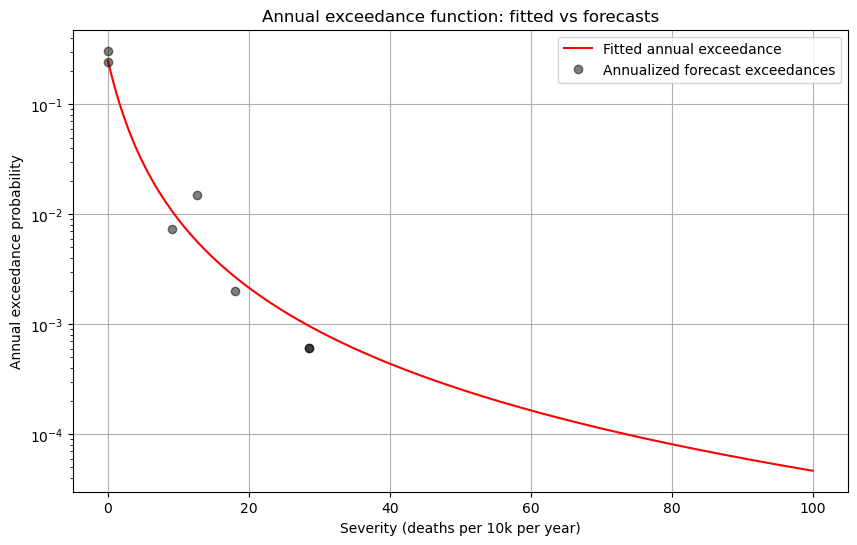

In [37]:
# Get best parameters from results (minimum RSS)
best_params = results_df.loc[results_df['rss'].idxmin()]
xi, sigma, lambda_ = best_params[['est_xi', 'est_sigma', 'est_lambda']]

# Create exceedance plot
plt.figure(figsize=(10, 6))

# Plot theoretical annual exceedance function with estimated parameters
x = np.linspace(mu, 100, 1000)  # Start from mu (lower bound)
annual_exceedance = arrival_prob(1, lambda_  * gpd_survival(x, xi, sigma))
plt.plot(x, annual_exceedance, 'r-', label='Fitted annual exceedance')

# Plot empirical exceedance from forecast data
# Convert forecasts to annual probabilities
plt.plot(forecasts['x'], forecasts['implied_annual_exc'], 'ko', alpha=0.5, label='Annualized forecast exceedances')

plt.xlabel('Intensity (deaths per 10k per year)')
plt.ylabel('Annual exceedance probability')
plt.title('Annual exceedance function: fitted vs forecasts')
plt.legend()
plt.grid(True)
plt.yscale('log')  # Log scale for better visualization of probabilities
plt.show()

It looks like our central prior predicts small pandemics more frequently, but larger ones much less frequently. Interesting!

Now we make ad hoc assumptions about weak priors over each of these parameters, making sure they are centere at the estimated values.

- Assume $\xi \sim N(\hat{\xi}, 4)$
- Assume $\sigma \sim LogNorm(ln(\hat{\sigma} + 2), 4)$
- Assume $p_0 \sim Beta(\alpha, \beta)$ s.t. $\alpha + \beta = 2$ and $\frac{\alpha}{\alpha + \beta} = 1 - e^{-\hat{\lambda}}$

## 3. Estimate full prior distributions using forecasts

The third approach involves using the forecast central moments *and* spread moments to estimate all the parameters of our prior distributions. I haven't implemented it yet, but the outline is below.

Pandemic arrival forecasts are subjective probabilities defined across binary outcomes (e.g., "Wil a pandemic of at least x severity emerge within t years?"). Naively, one can imagine that each person's forecast represents the central moment of a Beta distribution, where the $\alpha$ and $\beta$ define the units of evidence provided toward each outcome. The mixture of these forecast therefore also follows a Beta distribution, i.e.,:

$$q_i \sim Beta(\alpha_i, \beta_i)$$

(Thinking about forecasts as coming from a hierarchical model might make this intuition rigorous)

To calibrate our parameters, we further impose the following structure upon the forecasts

$$q_i = 1 - e^{\lambda t_i s_i(x_i)}$$

We then want to solve for distributions of $(\xi, \sigma, \lambda)$ that fit the expressed moments of the beta distribuion. We could start by making the following distributional assumptions.

| model parameter            | prior family (hyper-parameters to determine) | reason                                        |
| -------------------------- | -------------------------------------------- | --------------------------------------------- |
| **arrival rate** $\lambda$ | Gamma $(a,b)$                                 | mean & variance analytic; conjugate to counts |
| **scale** $\sigma$         | Log-Normal $(\mu_{ln(\sigma)},\tau_\sigma^2)$ | positive support; two free moments            |
| **shape** $\xi$            | Half-Normal $(\tau_\xi)$ (i.e. $\xi\ge0$)     | simplest two-moment positive law              |


We estimate $(\xi, \sigma, \lambda)$ by minimizing the squared error between forecasted probabilities and model-implied exceedance probabilities as above.

To yield full prior distributions, we assume a propagation variances using the delta method, i.e.,

$$Var(q_i) = \bigr(\frac{\partial q_i}{\partial \lambda}\bigr)^2 Var[\lambda] + \bigr(\frac{\partial q_i}{\partial \sigma}\bigr)^2 Var[\sigma] + \bigr(\frac{\partial q_i}{\partial \xi}\bigr)^2 Var[\xi]$$

We can then use linear regression to estimate the variances and, in combination with the central moments, estimate the fundamental prior parameters.

I haven't taken this approach yet, but let me know if it interests you.
